In [ ]:
import matplotlib.pyplot as plt
import jax.numpy as jnp
from jax import jit, value_and_grad, random, tree
from functools import partial
from tqdm import tqdm

plt.rcParams["axes.formatter.useoffset"] = False
plt.rcParams["xtick.labelsize"] = 20
plt.rcParams["ytick.labelsize"] = 20
plt.rcParams["axes.linewidth"] = 2
plt.rcParams["font.size"] = 30

In [2]:
key = random.PRNGKey(0)
key1, key2 = random.split(key)

x = random.uniform(key1, (100,), minval=-1, maxval=1)
y = 3.0 * x + 2.0 + 0.1 * random.normal(key2, (100,))

batch = (x, y)

params = (0.0, 0.0) # (w, b)

In [3]:
def loss_fn(params, batch):
    w, b = params
    x, y = batch
    y_pred = w * x + b
    return jnp.mean((y_pred - y)**2)

@partial(jit, static_argnums=(2,))
def step(params, batch, lr):
    loss, grads = value_and_grad(loss_fn)(params, batch)
    params = tree.map(lambda p, g: p - lr * g, params, grads)
    return params, loss

In [4]:
losses = []
lr = 0.01
epochs = 5000

for epoch in tqdm(range(epochs)):
    params, loss = step(params, batch, lr)
    losses.append(loss)

print("learned w, b:", tree.map(lambda p: p.item(), params))

  0%|          | 0/5000 [00:00<?, ?it/s]

100%|██████████| 5000/5000 [00:00<00:00, 13490.44it/s]


learned w, b: (2.9839680194854736, 2.028332471847534)


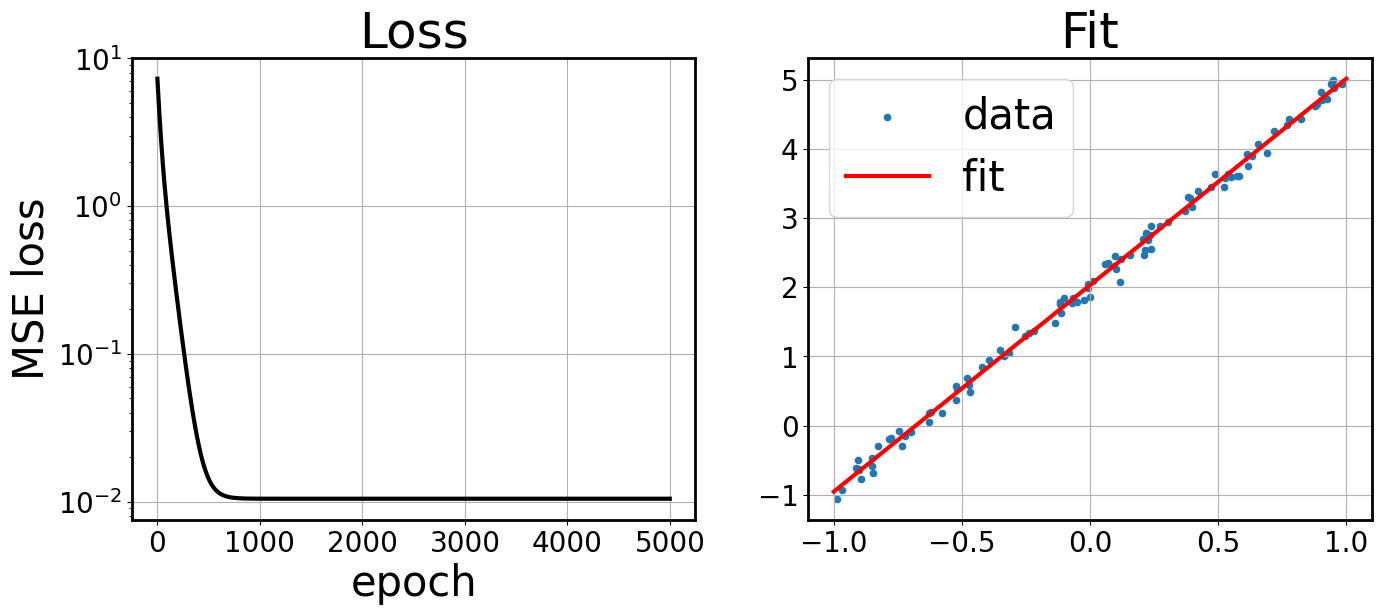

In [5]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(16,6))

axx = ax[0]
axx.plot(losses, lw=3, c="k")
axx.set_xlabel("epoch")
axx.set_ylabel("MSE loss")
axx.set_title("Loss")
axx.set_yscale("log")
axx.grid()

w, b = params
xs = jnp.linspace(-1.0, 1.0, 100)

axx = ax[1]
axx.scatter(x, y, s=20, label="data")
axx.plot(xs, w * xs + b, color="red", label="fit", lw=3)
axx.legend()
axx.set_title("Fit")
axx.grid()

plt.show()

### If you want to split the inputs and labels

In [6]:
key = random.PRNGKey(0)
key1, key2 = random.split(key)

x = random.uniform(key1, (100,), minval=-1, maxval=1)
y = 3.0 * x + 2.0 + 0.1 * random.normal(key2, (100,))

inputs = x
labels = y

params = (0.0, 0.0) # (w, b)

In [7]:
def loss_fn(params, inputs, lables):
    w, b = params
    x, y = inputs, lables
    y_pred = w * x + b
    return jnp.mean((y_pred - y)**2)

@partial(jit, static_argnums=(3,))
def step(params, inputs, lables, lr):
    loss, grads = value_and_grad(loss_fn)(params, inputs, lables)
    params = tree.map(lambda p, g: p - lr * g, params, grads)
    return params, loss

In [8]:
losses = []
lr = 0.01
epochs = 5000

for epoch in tqdm(range(epochs)):
    params, loss = step(params, inputs, labels, lr)
    losses.append(loss)

print("learned w, b:", tree.map(lambda p: p.item(), params))

100%|██████████| 5000/5000 [00:00<00:00, 15234.08it/s]

learned w, b: (2.9839680194854736, 2.028332471847534)


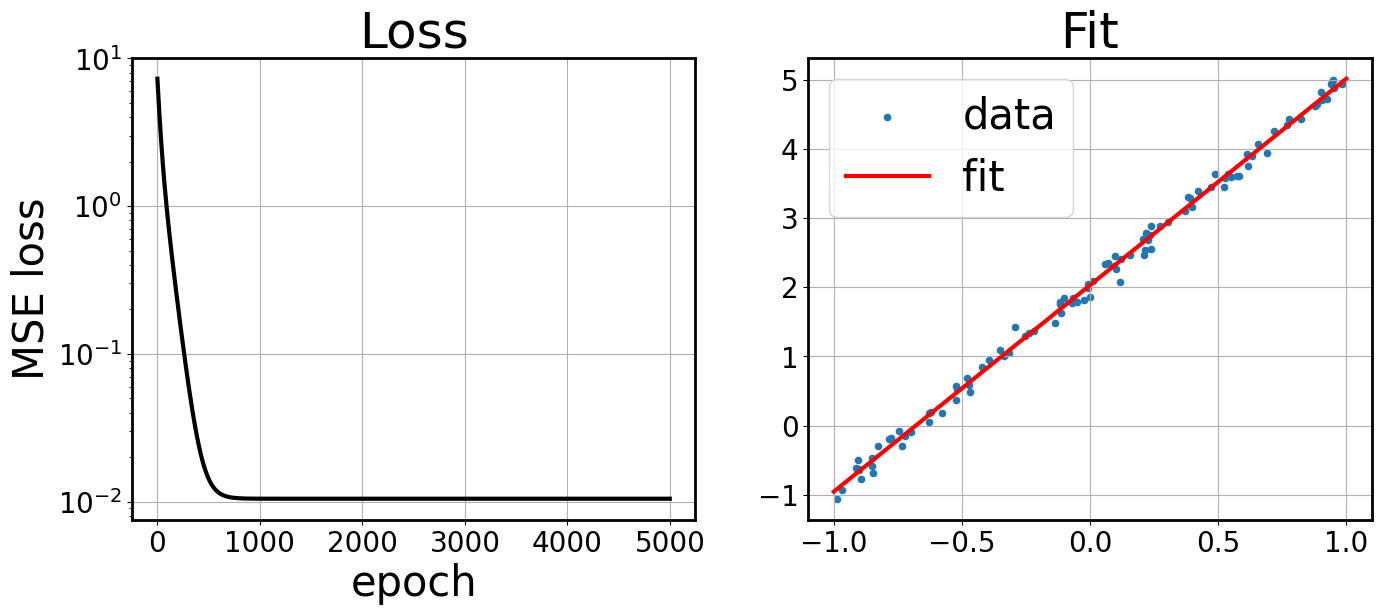

In [9]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(16,6))

axx = ax[0]
axx.plot(losses, lw=3, c="k")
axx.set_xlabel("epoch")
axx.set_ylabel("MSE loss")
axx.set_title("Loss")
axx.set_yscale("log")
axx.grid()

w, b = params
xs = jnp.linspace(-1.0, 1.0, 100)

axx = ax[1]
axx.scatter(x, y, s=20, label="data")
axx.plot(xs, w * xs + b, color="red", label="fit", lw=3)
axx.legend()
axx.set_title("Fit")
axx.grid()

plt.show()